# Kinetic analysis of a bichromatic fluorescent protein

This notebook visualizes fluorescence kinetics extracted from spectrofluorimeter data under alternating LED excitation.

## Experimental setup
The experiment consists of alternating excitation pulses:
- **400 nm**
- **560 nm**

For each excitation regime, fluorescence kinetics were extracted at:
- **520 nm** (green emission)
- **580 nm** (red emission)

To reduce noise, intensities were averaged within **±0.5 nm** around each target wavelength.

## Goal
The goal is to compare fluorescence behavior under different excitation wavelengths and assess whether the observed dynamics are consistent with wavelength-dependent excitation and/or photoconversion of spectrally distinct states of the protein.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

imp400_520 = pd.read_csv("imp400_inten_520.csv", header=None, names=["time", "intensity"])
imp400_580 = pd.read_csv("imp400_inten_580.csv", header=None, names=["time", "intensity"])
imp560_520 = pd.read_csv("imp560_inten_520.csv", header=None, names=["time", "intensity"])
imp560_580 = pd.read_csv("imp560_inten_580.csv", header=None, names=["time", "intensity"])

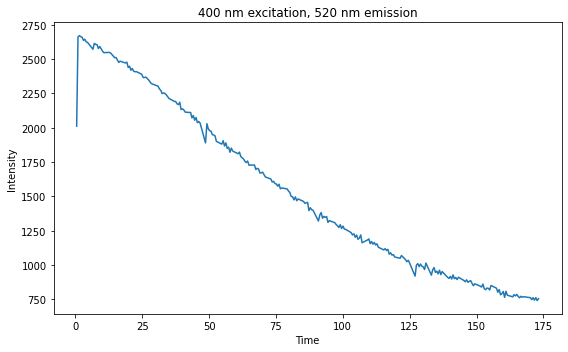

In [2]:
plt.figure(figsize=(8, 5))
plt.plot(imp400_520["time"], imp400_520["intensity"])
plt.xlabel("Time")
plt.ylabel("Intensity")
plt.title("400 nm excitation, 520 nm emission")
plt.tight_layout()
plt.show()

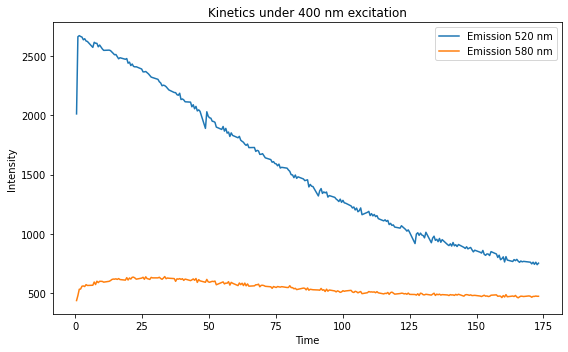

In [3]:
plt.figure(figsize=(8, 5))
plt.plot(imp400_520["time"], imp400_520["intensity"], label="Emission 520 nm")
plt.plot(imp400_580["time"], imp400_580["intensity"], label="Emission 580 nm")
plt.xlabel("Time")
plt.ylabel("Intensity")
plt.title("Kinetics under 400 nm excitation")
plt.legend()
plt.tight_layout()
plt.show()

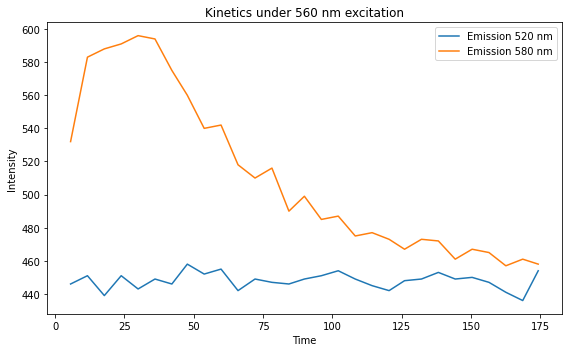

In [4]:
plt.figure(figsize=(8, 5))
plt.plot(imp560_520["time"], imp560_520["intensity"], label="Emission 520 nm")
plt.plot(imp560_580["time"], imp560_580["intensity"], label="Emission 580 nm")
plt.xlabel("Time")
plt.ylabel("Intensity")
plt.title("Kinetics under 560 nm excitation")
plt.legend()
plt.tight_layout()
plt.show()

## Initial observations

Under **400 nm excitation**, the signal at **520 nm** is much stronger than the signal at **580 nm** and gradually decreases over time.

Under **560 nm excitation**, the signal at **580 nm** is relatively more pronounced, while the **520 nm** signal remains lower and changes less strongly.

Because the absolute intensity scales differ between 520 nm and 580 nm, it is useful to also compare **normalized kinetics** to focus on the shape of the response rather than absolute magnitude.

In [5]:
def normalize(df):
    out = df.copy()
    out["intensity"] = out["intensity"] / out["intensity"].max()
    return out

n400_520 = normalize(imp400_520)
n400_580 = normalize(imp400_580)
n560_520 = normalize(imp560_520)
n560_580 = normalize(imp560_580)

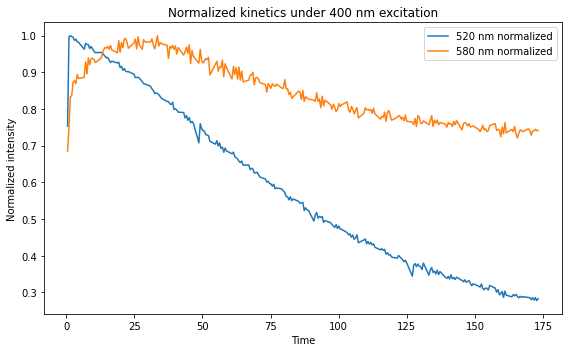

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(n400_520["time"], n400_520["intensity"], label="520 nm normalized")
plt.plot(n400_580["time"], n400_580["intensity"], label="580 nm normalized")
plt.xlabel("Time")
plt.ylabel("Normalized intensity")
plt.title("Normalized kinetics under 400 nm excitation")
plt.legend()
plt.tight_layout()
plt.show()

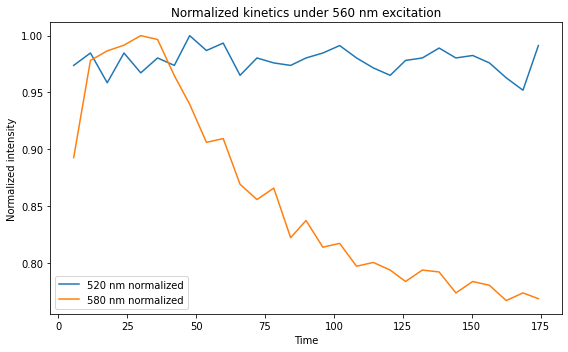

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(n560_520["time"], n560_520["intensity"], label="520 nm normalized")
plt.plot(n560_580["time"], n560_580["intensity"], label="580 nm normalized")
plt.xlabel("Time")
plt.ylabel("Normalized intensity")
plt.title("Normalized kinetics under 560 nm excitation")
plt.legend()
plt.tight_layout()
plt.show()

Under 400 nm excitation, the signal at 520 nm is substantially higher than at 580 nm and shows a gradual decay over time. This suggests that 400 nm illumination preferentially excites or enriches the green-emitting state of the bichromatic fluorescent protein.

The weaker signal at 580 nm under 400 nm excitation is consistent with a lower contribution of the red-emitting state in these conditions.

Under 560 nm excitation, the 580 nm signal is relatively more pronounced, while the 520 nm signal remains lower and nearly flat. This pattern is consistent with preferential excitation or accumulation of the red-emitting form under 560 nm illumination.

## Conclusion

This notebook shows that fluorescence kinetics extracted at **520 nm** and **580 nm** differ depending on whether the sample is illuminated with **400 nm** or **560 nm** pulses.

The strongest response was observed for **400 nm excitation / 520 nm emission**, which is consistent with preferential excitation or accumulation of a green-emitting state of the bichromatic fluorescent protein.

Overall, the data support wavelength-dependent spectral behavior and are consistent with excitation-dependent redistribution between distinct fluorescent states.